In [299]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [300]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [301]:
# Leer datos separados por una coma
# data = np.loadtxt('ex1data1.txt', delimiter=',')
# data = np.loadtxt(os.path.join('data', 'ex1data1.txt'), delimiter=',')
data = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/DATASETS/price-area1.txt', delimiter=',')
# Seleccionar solo las primeras 100 filas
data = data[:10000, :]
X, y = data[:, 0], data[:, 1]

m = y.size  # m = numero de ejemplos de entrenamiento

In [302]:
print(data)

[[ 24.513   30.3   ]
 [ 14.5     33.    ]
 [107.      85.    ]
 ...
 [145.48    61.    ]
 [ 29.5     30.    ]
 [ 25.2247  39.5   ]]


In [303]:
print(X)

[ 24.513   14.5    107.     ... 145.48    29.5     25.2247]


In [304]:
print(y)

[30.3 33.  85.  ... 61.  30.  39.5]


In [305]:
print(X.size)

10000


In [306]:
def plotData(x, y):
    #Grafica los puntos x e y en una figura nueva.

    fig = pyplot.figure()  # abre una nueva figura

    pyplot.plot(x, y, 'ro', ms=7, mec='k')
    pyplot.ylabel('precio del terreno')
    pyplot.xlabel('area del terreno')



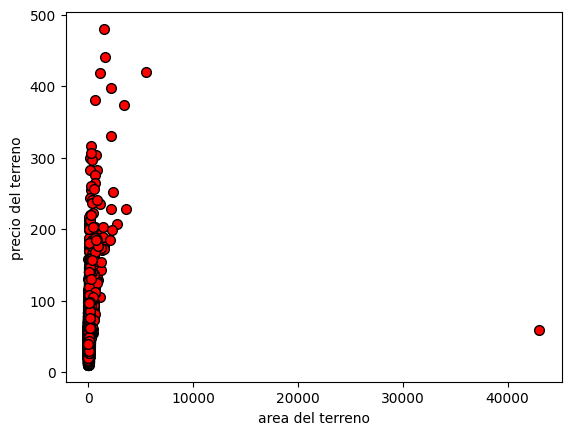

In [307]:
plotData(X, y)

In [308]:
# Agrega una columna de unos a X. La funcion stack de numpy une matrices a lo largo de un eje dado.
# El primer eje (eje = 0) se refiere a filas (ejemplos de entrenamiento)
# y el segundo eje (eje = 1) se refiere a columnas (características).

X = np.stack([np.ones(m), X], axis=1)

In [309]:
print(X)

[[  1.      24.513 ]
 [  1.      14.5   ]
 [  1.     107.    ]
 ...
 [  1.     145.48  ]
 [  1.      29.5   ]
 [  1.      25.2247]]


In [310]:
def calcularCosto(X, y, theta):
    # inicializa algunos valores importantes
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    # h = np.dot(X, theta)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [311]:
J = calcularCosto(X, y, theta=np.array([0.0, 0.0]))
print('Con theta = [0, 0] \n Costo calculado = %.2f' % J)
# print('Valor de costo esperado (aproximadamente) 32.07\n')

# pruebas adicionales de la función de costes
J = calcularCosto(X, y, theta=np.array([0.5, 0.5]))
print('Con theta = [0.5, 0.5]\n Costo calculado = %.2f' % J)
# print('Valor de costo esperado (aproximadamente)  54.24')

J = calcularCosto(X, y, theta=np.array([0.6, 0.6]))
print('Con theta = [0.6, 0.6]\n Costo calculado = %.2f' % J)

J = calcularCosto(X, y, theta=np.array([0.7, 0.7]))
print('Con theta = [0.7, 0.7]\n Costo calculado = %.2f' % J)

J = calcularCosto(X, y, theta=np.array([0.8, 0.8]))
print('Con theta = [0.8, 0.8]\n Costo calculado = %.2f' % J)

J = calcularCosto(X, y, theta=np.array([0.75, 0.75]))
print('Con theta = [0.75, 0.75]\n Costo calculado = %.2f' % J)

Con theta = [0, 0] 
 Costo calculado = 1922.18
Con theta = [0.5, 0.5]
 Costo calculado = 24647.29
Con theta = [0.6, 0.6]
 Costo calculado = 35327.91
Con theta = [0.7, 0.7]
 Costo calculado = 48053.72
Con theta = [0.8, 0.8]
 Costo calculado = 62824.73
Con theta = [0.75, 0.75]
 Costo calculado = 55183.57


In [312]:
def gradientDescent(X, y, theta, alpha, num_iters):
        # Inicializa algunos valores importantes
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # hace una copia de theta, para evitar cambiar la matriz original,
    # ya que las matrices numpy se pasan por referencia a las funciones

    theta = theta.copy()

    J_history = [] # Lista que se utiliza para almacenar el costo en cada iteración

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        # save the cost J in every iteration
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

In [317]:
# inicializa los parametros de ajuste
theta = np.zeros(2)

# configuraciones para el descenso por el gradiente
iterations = 10000
alpha = 0.000001 # Reducir la tasa de aprendizaje

theta, J_history = gradientDescent(X ,y, theta, alpha, iterations)
print('Theta encontrada por descenso gradiente: {:.4f}, {:.4f}'.format(*theta))
print('Valores theta esperados (aproximadamente): [-3.6303, 1.1664]')
print(J_history)

Theta encontrada por descenso gradiente: 0.5285, 0.0274
Valores theta esperados (aproximadamente): [-3.6303, 1.1664]
[np.float64(1893.7709942111874), np.float64(1875.7875976555988), np.float64(1864.4031588233129), np.float64(1857.1958285020937), np.float64(1852.6325877855886), np.float64(1849.743043077303), np.float64(1847.912939896605), np.float64(1846.7534581107782), np.float64(1846.018476445381), np.float64(1845.5522013171171), np.float64(1845.2560161368635), np.float64(1845.0674970778846), np.float64(1844.94713015801), np.float64(1844.8699032165193), np.float64(1844.819983675945), np.float64(1844.7873495908764), np.float64(1844.765657118058), np.float64(1844.7508906352118), np.float64(1844.7405082727441), np.float64(1844.7329010394246), np.float64(1844.7270504515411), np.float64(1844.7223118137995), np.float64(1844.7182770371808), np.float64(1844.714687803296), np.float64(1844.7113805978493), np.float64(1844.7082519170751), np.float64(1844.7052362435893), np.float64(1844.7022921052

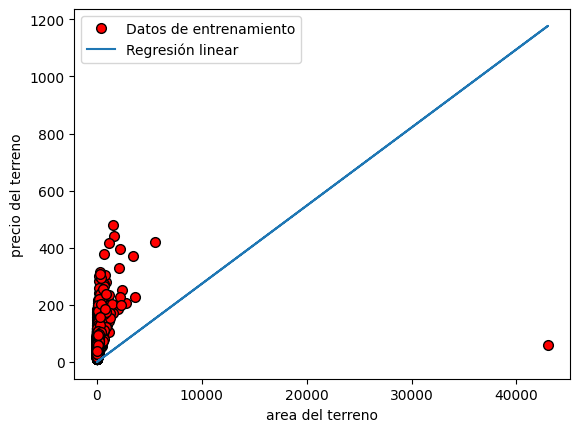

In [318]:
# grafica la linea de ajuste
plotData(X[:, 1], y)
pyplot.plot(X[:, 1], np.dot(X, theta), '-')
pyplot.legend(['Datos de entrenamiento', 'Regresión linear']);

In [315]:
# Predecir valores de beneficio para poblaciones de 35,000 y 70,000
predict1 = np.dot([1, 8.47], theta)
print('Para una población = 84,700, se predice un beneficio de {:.2f}\n'.format(predict1*10000))

predict2 = np.dot([1, 9], theta)
print('Para una población de = 90,000, se predice un beneficio de {:.2f}\n'.format(predict2*10000))

Para una población = 84,700, se predice un beneficio de nan

Para una población de = 90,000, se predice un beneficio de nan



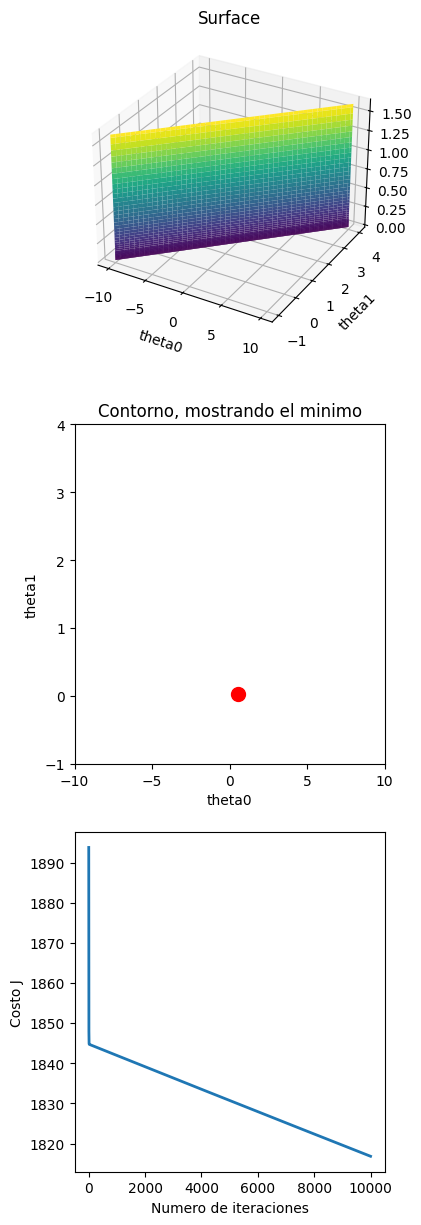

In [319]:
# cuadrícula sobre la que se calcula J
theta0_vals = np.linspace(-10, 10, 100)
theta1_vals = np.linspace(-1, 4, 100)

# inicializa J_vals con una matriz de 0's
J_vals = np.zeros((theta0_vals.shape[0], theta1_vals.shape[0]))

# Completar J_vals
for i, theta0 in enumerate(theta0_vals):
    for j, theta1 in enumerate(theta1_vals):
        J_vals[i, j] = calcularCosto(X, y, [theta0, theta1])

# Debido a la forma en que funcionan las cuadrículas en el comando surf,
# se necesita transponer J_vals antes de llamar a surf, o de lo contrario los ejes se invertirán
J_vals = J_vals.T

# graficar la superficie
fig = pyplot.figure(figsize=(4, 15))
ax = fig.add_subplot(311, projection='3d')
ax.plot_surface(theta0_vals, theta1_vals, J_vals, cmap='viridis')
pyplot.xlabel('theta0')
pyplot.ylabel('theta1')
pyplot.title('Surface')

# graficar contornos
# Grafica J_vals como 15 contours spaciados logaritmicamente entre 0.01 y 100
ax = pyplot.subplot(312)
pyplot.contour(theta0_vals, theta1_vals, J_vals, linewidths=2, cmap='viridis', levels=np.logspace(-2, 3, 20))
pyplot.xlabel('theta0')
pyplot.ylabel('theta1')
pyplot.plot(theta[0], theta[1], 'ro', ms=10, lw=2)
pyplot.title('Contorno, mostrando el minimo')


# Grafica la convergencia del costo
ax = pyplot.subplot(313)
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

pass